# Core 4-country portfolio client notebook

Portefeuille de reference gele : **France + Sweden + Netherlands + Germany mitigated**.

Ce notebook charge les series mensuelles figees, affiche les livres et parametres retenus, calcule les poids simples, puis trace l'equity curve, le drawdown et les diagnostics de diversification.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
if not (ROOT / 'config' / 'core_portfolio_reference.json').exists():
    ROOT = ROOT.parent
if not (ROOT / 'config' / 'core_portfolio_reference.json').exists():
    raise FileNotFoundError('Run this notebook from the repo root or from the notebook/ folder.')

CONFIG_PATH = ROOT / 'config' / 'core_portfolio_reference.json'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    CONFIG = json.load(f)

print(f"Repo root: {ROOT}")
print(f"Portfolio: {CONFIG['portfolio_id']} | status={CONFIG['status']} | frozen_at={CONFIG['frozen_at']}")


Repo root: d:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal
Portfolio: core_4_country_v1 | status=frozen_reference | frozen_at=2026-04-21


## Parametres figes du portefeuille

In [2]:
books = pd.DataFrame(CONFIG['books'])
cols = ['book', 'country', 'role', 'config_name', 'logic', 'maturity_status', 'notes']
display(books[cols])

print('Periode:', CONFIG['period']['start'], '->', CONFIG['period']['end'])
print('Weighting par defaut:', CONFIG['default_weight_scheme'])
print('Methodologie:', CONFIG['methodology_note'])


,book,country,role,config_name,logic,maturity_status,notes
0,france,france,core_book,reference,France local reference baseline,top_pf_qualified,France enters as a simple local baseline book.
1,sweden,sweden,core_book,best_plus_regime_filter,Sweden local C regime filter,advanced_local_validated,Sweden uses the locally validated regime-filte...
2,netherlands,netherlands,supporting_book,reference,Netherlands local reference baseline,top_pf_qualified_supporting,Netherlands is retained as a simple diversifyi...
3,germany,germany,core_book,pair_filter_corr_abs_le_0p75_bypass_scan_stres...,Germany corr<=0.75 pair filter with scan-time ...,shadow_validation_promoted,Germany enters after shadow validation; 2025 s...


Periode: 2018-01-01 -> 2025-12-31
Weighting par defaut: inverse_vol
Methodologie: Frozen client reference built from fixed local country books. No cross-country universal trading rule, no Markowitz optimization, no retuning in this notebook.


## Chargement des rendements mensuels par livre

In [12]:
def normalize_month(value):
    dt = pd.to_datetime(value, errors='coerce')
    if isinstance(dt, pd.Series):
        return dt.dt.to_period('M').dt.to_timestamp()
    return dt.to_period('M').to_timestamp()


def load_book_returns(book_cfg: dict) -> pd.DataFrame:
    path = ROOT / book_cfg['source_dir'] / book_cfg['source_file']
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    if 'trade_month' not in df.columns or 'month_return' not in df.columns:
        raise ValueError(f'Missing trade_month/month_return in {path}')
    df = df.copy()
    df['trade_month'] = normalize_month(df['trade_month'])
    df['month_return'] = pd.to_numeric(df['month_return'], errors='coerce')
    if 'config_name' in df.columns:
        df = df[df['config_name'].astype(str).eq(str(book_cfg['source_config_name']))].copy()
    if 'book' in df.columns:
        df = df[df['book'].astype(str).eq(str(book_cfg['source_book']))].copy()
    df['book'] = book_cfg['book']
    df['country'] = book_cfg['country']
    df['config_name'] = book_cfg['config_name']
    df = df[['trade_month', 'book', 'country', 'config_name', 'month_return']]
    return df.dropna(subset=['trade_month', 'month_return']).sort_values('trade_month')

monthly = pd.concat([load_book_returns(b) for b in CONFIG['books']], ignore_index=True)
start = pd.Timestamp(CONFIG['period']['start']).to_period('M').to_timestamp()
end = pd.Timestamp(CONFIG['period']['end']).to_period('M').to_timestamp()
monthly = monthly[(monthly['trade_month'] >= start) & (monthly['trade_month'] <= end)].copy()

returns = monthly.pivot_table(index='trade_month', columns='book', values='month_return', aggfunc='sum').sort_index().fillna(0.0)
print(f'Months: {len(returns)} | start={returns.index.min().date()} | end={returns.index.max().date()}')
display(returns.tail())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trade_month   384 non-null    object 
 1   month_return  384 non-null    float64
 2   config_name   384 non-null    object 
 3   book          384 non-null    object 
 4   country       384 non-null    object 
dtypes: float64(1), object(4)
memory usage: 15.1+ KB
Months: 96 | start=2018-01-01 | end=2025-12-01


book,france,germany,netherlands,sweden
trade_month,,,,
2025-08-01,0.131149,0.002778,0.006103,0.064918
2025-09-01,0.037376,0.025465,0.041125,-0.002759
2025-10-01,-0.107415,0.172674,-0.045736,-0.013243
2025-11-01,0.000000,-0.018177,0.045411,0.101743
2025-12-01,0.031368,-0.118637,0.050776,0.047576


## Fonctions de metrics et de pond?ration

In [4]:
def max_drawdown(series: pd.Series):
    equity = (1.0 + series.fillna(0.0)).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1.0
    trough = dd.idxmin()
    peak_date = equity.loc[:trough].idxmax() if len(equity) else pd.NaT
    return float(dd.loc[trough]), peak_date, trough, equity, dd


def return_metrics(series: pd.Series, periods_per_year: int = 12) -> dict:
    r = pd.to_numeric(series, errors='coerce').dropna()
    if r.empty:
        return {}
    total_return = float((1.0 + r).prod() - 1.0)
    ann_return = float((1.0 + total_return) ** (periods_per_year / len(r)) - 1.0) if total_return > -1 else -1.0
    ann_vol = float(r.std(ddof=1) * np.sqrt(periods_per_year)) if len(r) > 1 else np.nan
    sharpe = float((r.mean() / r.std(ddof=1)) * np.sqrt(periods_per_year)) if len(r) > 1 and r.std(ddof=1) > 0 else np.nan
    dd, dd_start, dd_end, _eq, _drawdown = max_drawdown(r)
    return {
        'n_months': int(len(r)),
        'total_return': total_return,
        'annualized_return': ann_return,
        'annualized_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': dd,
        'dd_start': dd_start,
        'dd_end': dd_end,
        'positive_month_rate': float((r > 0).mean()),
        'worst_month': float(r.min()),
        'best_month': float(r.max()),
    }


def compute_weights(returns: pd.DataFrame, scheme: str) -> pd.Series:
    if scheme == 'equal_weight':
        return pd.Series(1.0 / returns.shape[1], index=returns.columns)
    if scheme == 'inverse_vol':
        vol = returns.std(ddof=1).replace(0, np.nan)
        inv = 1.0 / vol
        if inv.isna().any() or inv.sum() <= 0:
            raise ValueError('Cannot compute inverse_vol weights from current return matrix.')
        return inv / inv.sum()
    raise ValueError(f'Unknown weight scheme: {scheme}')


def portfolio_returns(returns: pd.DataFrame, weights: pd.Series) -> pd.Series:
    weights = weights.reindex(returns.columns).fillna(0.0)
    return returns.mul(weights, axis=1).sum(axis=1)


## Synthese par livre

In [5]:
book_summary = []
for book in returns.columns:
    m = return_metrics(returns[book])
    book_summary.append({'book': book, **m})
book_summary = pd.DataFrame(book_summary).sort_values('sharpe', ascending=False)
display(book_summary[['book', 'total_return', 'annualized_return', 'annualized_vol', 'sharpe', 'max_drawdown', 'positive_month_rate', 'worst_month', 'best_month']])


,book,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,positive_month_rate,worst_month,best_month
1,germany,3.974905,0.222076,0.224420,1.009946,-0.176083,0.510417,-0.176083,0.224837
3,sweden,2.101524,0.151985,0.189531,0.843149,-0.299032,0.552083,-0.123753,0.174840
0,france,3.248520,0.198201,0.278306,0.788133,-0.255857,0.541667,-0.193226,0.307813
2,netherlands,1.025312,0.092223,0.139590,0.702207,-0.319684,0.385417,-0.103056,0.111723


## Construction du portefeuille

In [6]:
WEIGHT_SCHEME = CONFIG['default_weight_scheme']  # 'inverse_vol' ou 'equal_weight'
weights = compute_weights(returns, WEIGHT_SCHEME)
port_ret = portfolio_returns(returns, weights)
metrics = return_metrics(port_ret)
dd, dd_start, dd_end, equity, drawdown = max_drawdown(port_ret)

weights_frame = weights.rename('weight').reset_index().rename(columns={'index': 'book'})
display(Markdown(f"### Poids utilises: `{WEIGHT_SCHEME}`"))
display(weights_frame)

display(Markdown('### Metrics portefeuille'))
display(pd.DataFrame([metrics]).T.rename(columns={0: 'value'}))


### Poids utilises: `inverse_vol`

,book,weight
0,france,0.175369
1,germany,0.217478
2,netherlands,0.349641
3,sweden,0.257512


### Metrics portefeuille

,value
n_months,96
total_return,2.556518
annualized_return,0.171866
annualized_vol,0.085102
sharpe,1.917477
max_drawdown,-0.085054
dd_start,2023-01-01 00:00:00
dd_end,2023-04-01 00:00:00
positive_month_rate,0.677083
worst_month,-0.053013


## Equity curve et drawdown

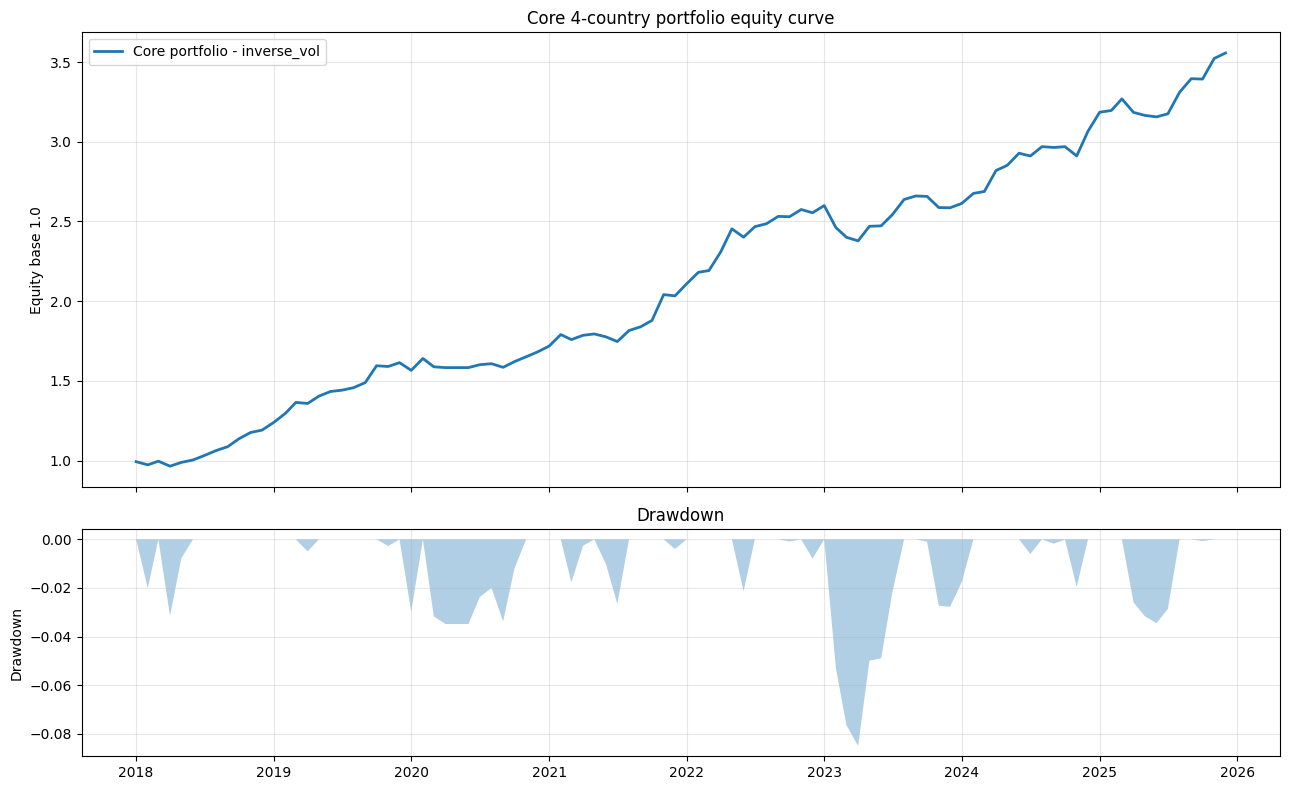

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(equity.index, equity.values, linewidth=2, label=f'Core portfolio - {WEIGHT_SCHEME}')
axes[0].set_title('Core 4-country portfolio equity curve')
axes[0].set_ylabel('Equity base 1.0')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.35)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Contributions et diversification

,book,weight,weighted_total_return,sum_weighted_monthly_returns
1,germany,0.217478,0.468425,0.394335
3,sweden,0.257512,0.376158,0.329209
0,france,0.175369,0.347031,0.307728
2,netherlands,0.349641,0.302707,0.274178


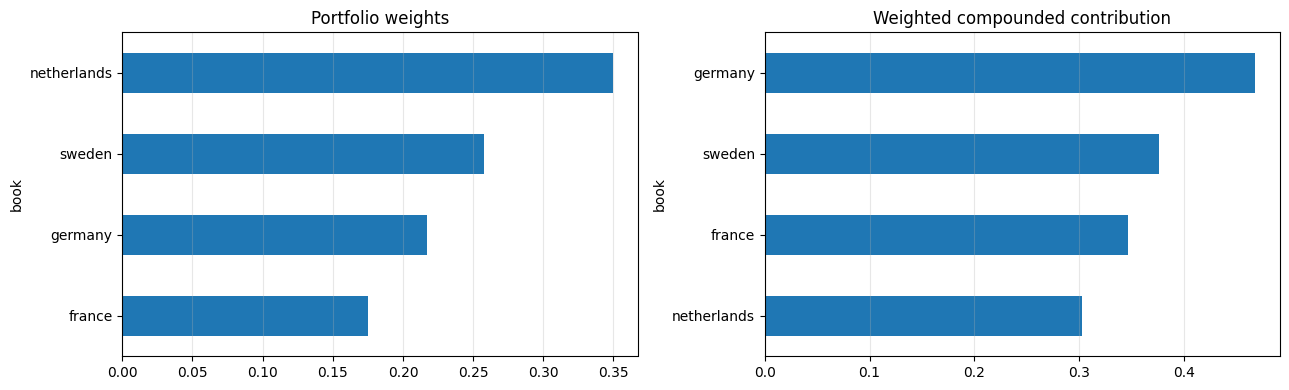

In [8]:
weighted_returns = returns.mul(weights, axis=1)
contrib_total = ((1.0 + weighted_returns).prod() - 1.0).rename('weighted_total_return')
contrib_simple = weighted_returns.sum().rename('sum_weighted_monthly_returns')
contrib = pd.concat([weights.rename('weight'), contrib_total, contrib_simple], axis=1).reset_index().rename(columns={'index': 'book'})
display(contrib.sort_values('weighted_total_return', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
weights.sort_values().plot(kind='barh', ax=axes[0], title='Portfolio weights')
contrib_total.sort_values().plot(kind='barh', ax=axes[1], title='Weighted compounded contribution')
for ax in axes:
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlation entre livres

book,france,germany,netherlands,sweden
book,,,,
france,1.000000,-0.214322,-0.173914,0.090507
germany,-0.214322,1.000000,-0.041816,-0.036580
netherlands,-0.173914,-0.041816,1.000000,-0.103692
sweden,0.090507,-0.036580,-0.103692,1.000000


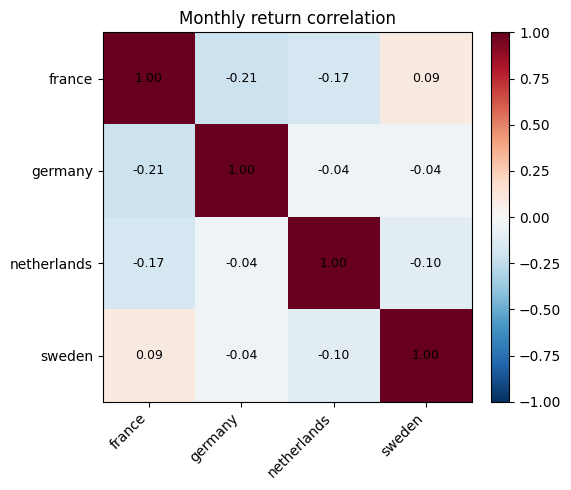

In [9]:
corr = returns.corr()
display(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Monthly return correlation')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Fenetres recentes de controle

In [10]:
windows = {
    '2023_2025': ('2023-01-01', '2025-12-31'),
    '2024_2025': ('2024-01-01', '2025-12-31'),
    '2025': ('2025-01-01', '2025-12-31'),
}
rows = []
for name, (s, e) in windows.items():
    mask = (returns.index >= pd.Timestamp(s)) & (returns.index <= pd.Timestamp(e))
    r = returns.loc[mask]
    if r.empty:
        continue
    w = compute_weights(r, WEIGHT_SCHEME)
    pr = portfolio_returns(r, w)
    rows.append({'window': name, 'start': s, 'end': e, **return_metrics(pr)})
recent_summary = pd.DataFrame(rows)
display(recent_summary[['window', 'total_return', 'annualized_return', 'annualized_vol', 'sharpe', 'max_drawdown', 'positive_month_rate', 'worst_month']])


,window,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,positive_month_rate,worst_month
0,2023_2025,0.398559,0.118305,0.081208,1.422611,-0.084628,0.666667,-0.051219
1,2024_2025,0.372170,0.171396,0.071877,2.249413,-0.035291,0.750000,-0.026363
2,2025,0.157857,0.157857,0.072732,2.060537,-0.033882,0.666667,-0.026527


## Export optionnel des series client

In [11]:
EXPORT_CLIENT_SERIES = False
if EXPORT_CLIENT_SERIES:
    out_dir = ROOT / 'data' / 'experiments' / 'core_portfolio_reference_client_exports'
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({'trade_month': port_ret.index, 'portfolio_month_return': port_ret.values}).to_csv(out_dir / 'portfolio_monthly_returns.csv', index=False)
    returns.to_csv(out_dir / 'book_monthly_returns_wide.csv')
    weights_frame.to_csv(out_dir / 'portfolio_weights.csv', index=False)
    print('Exported to', out_dir)
else:
    print('EXPORT_CLIENT_SERIES=False. Passe a True pour ecrire les exports client.')


EXPORT_CLIENT_SERIES=False. Passe a True pour ecrire les exports client.


## Notes de lecture

- Le portefeuille est une **reference gelee** : le notebook ne retune aucun pays et ne cherche aucun nouveau poids optimise.
- Le schema par defaut est `inverse_vol`; `equal_weight` reste disponible en changeant `WEIGHT_SCHEME`.
- Germany utilise la version promue apres shadow validation : `pair_filter_corr_abs_le_0p75_bypass_scan_stress_trending`.
- Le point de vigilance principal reste Germany 2025 standalone, a surveiller au niveau livre mais non bloquant au niveau portefeuille core.
